In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import os

sys.path.append(os.path.abspath(".."))

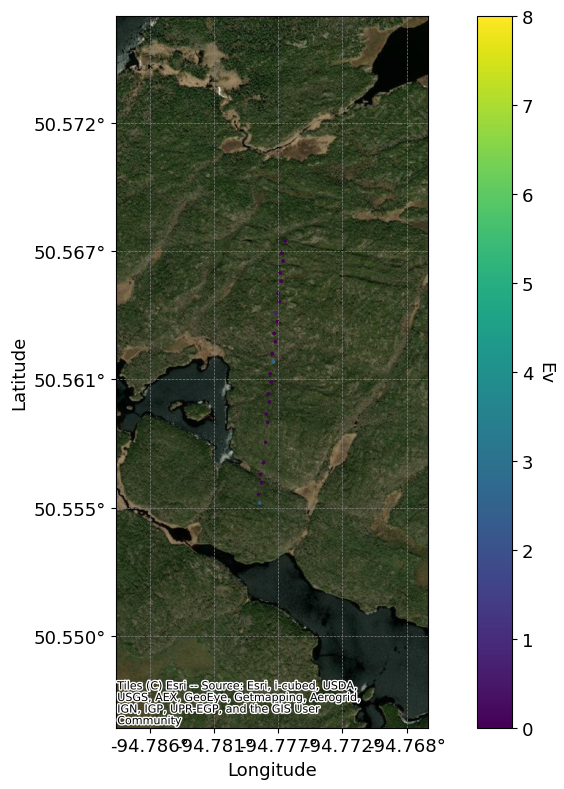

In [11]:
from scripts.track_pairs import *
from scripts.show_tracks_v2 import *
from pathlib import Path
from datetime import datetime
import yaml

def atl08_date_from_path(atl08_path):
    name = Path(atl08_path).name
    datestr = name.split('_')[1][:8]   # YYYYMMDD
    return datetime.strptime(datestr, "%Y%m%d")

with open("../config.yaml", "r") as f_cfg:
    cfg = yaml.safe_load(f_cfg)

# dirpaths = ['../../scratch/ontario_test/']
dirpaths = ['../../ontario_test/']

for dirpath in dirpaths:

    all_ATL03, all_ATL08, failed_ATL03 = track_pairs(dirpath, failed=True)
    f = [0]
    date_dt = atl08_date_from_path(all_ATL03[f[0]])
    date_str = date_dt.strftime("%d %B %Y")   # e.g. "04 March 2019"

    big_df = show_tracks(dirpath,[all_ATL03[i] for i in f], [all_ATL08[i] for i in f], cfg)

vmin = 0
vmax = 8
plot_static_map(big_df, c='Ev', cmap='viridis', vmin=vmin, vmax=vmax)